# Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#  Load Raw Dataset

In [3]:
df = pd.read_csv("../data/raw/StudentPerformanceFactors.csv")

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


# Initial Dataset Inspection

In [4]:
df.shape

(6607, 20)

In [5]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='str')

In [6]:
df.dtypes

Hours_Studied                 int64
Attendance                    int64
Parental_Involvement            str
Access_to_Resources             str
Extracurricular_Activities      str
Sleep_Hours                   int64
Previous_Scores               int64
Motivation_Level                str
Internet_Access                 str
Tutoring_Sessions             int64
Family_Income                   str
Teacher_Quality                 str
School_Type                     str
Peer_Influence                  str
Physical_Activity             int64
Learning_Disabilities           str
Parental_Education_Level        str
Distance_from_Home              str
Gender                          str
Exam_Score                    int64
dtype: object

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [8]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [9]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["Parental_Involvement"].unique()


<ArrowStringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

In [12]:
df["Motivation_Level"].unique()

<ArrowStringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

In [13]:
df["Access_to_Resources"].unique()

<ArrowStringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str

## Initial Dataset Observations

- The dataset contains 6607 rows and 20 columns.
- The target variable is "Exam_Score".
- There are  78 in Teacher_Quality cloumn,90 in Parental_Education_Level,67   in Distance_from_Home cloumn missing values.
- There are 0 duplicate rows.
- The dataset contains both numerical and categorical variables.
- One potential issue I noticed is that some columns contain missing values, which need to be fixe before analysis.

## Data Cleaning

In [14]:
df_clean = df.copy()

In [15]:
df_clean[[
    "Teacher_Quality",
    "Parental_Education_Level",
    "Distance_from_Home"
]].dtypes

Teacher_Quality             str
Parental_Education_Level    str
Distance_from_Home          str
dtype: object

In [16]:
df_clean["Teacher_Quality"].value_counts()

Teacher_Quality
Medium    3925
High      1947
Low        657
Name: count, dtype: int64

In [17]:
df_clean["Teacher_Quality"].value_counts(dropna=False)

Teacher_Quality
Medium    3925
High      1947
Low        657
NaN         78
Name: count, dtype: int64

In [18]:
df_clean["Parental_Education_Level"].value_counts(dropna=False)

Parental_Education_Level
High School     3223
College         1989
Postgraduate    1305
NaN               90
Name: count, dtype: int64

In [19]:
df_clean["Distance_from_Home"].value_counts(dropna=False)

Distance_from_Home
Near        3884
Moderate    1998
Far          658
NaN           67
Name: count, dtype: int64

In [20]:
missing_counts = df_clean.isnull().sum()
missing_counts[missing_counts > 0]

Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

In [21]:
missing_percentage = (
    df_clean.isnull().mean() * 100
).round(2)

missing_percentage[missing_percentage > 0]

Teacher_Quality             1.18
Parental_Education_Level    1.36
Distance_from_Home          1.01
dtype: float64

In [22]:
categorical_columns = [
    "Teacher_Quality",
    "Parental_Education_Level",
    "Distance_from_Home"
]

for column in categorical_columns:
    df_clean[column] = df_clean[column].fillna("Unknown")

In [23]:
df_clean.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

In [24]:
df_clean.shape

(6607, 20)

In [25]:
df_clean.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [26]:
df_clean["Attendance"].min(), df_clean["Attendance"].max()


(np.int64(60), np.int64(100))

In [27]:
df_clean["Exam_Score"].min(), df_clean["Exam_Score"].max()

(np.int64(55), np.int64(101))

In [28]:
df_clean[df_clean["Exam_Score"] > 100]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101


In [29]:
df_clean["Exam_Score"].value_counts().sort_index().tail(10)

Exam_Score
92     2
93     2
94     4
95     2
96     1
97     3
98     3
99     2
100    1
101    1
Name: count, dtype: int64

In [30]:
df_clean["Exam_Score"].describe()

count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64

In [31]:
df_clean[df_clean["Exam_Score"] > 100]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101


In [32]:
df_clean.loc[df_clean["Exam_Score"] > 100, "Exam_Score"] = 100

In [33]:
df_clean["Exam_Score"].max()

np.int64(100)

In [34]:
df_clean[df_clean["Exam_Score"] > 100]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score


### Invalid Exam Score

One record contained an `Exam_Score` of 101, which is outside the expected 0–100 scoring range.

The record was not removed because the other student information was still valid. Instead, the score was corrected from 101 to 100, treating it as a data-entry error.

After correction, the maximum `Exam_Score` is 100.

In [35]:
print("Shape:", df_clean.shape)
print("\nMissing values:")
print(df_clean.isnull().sum())
print("\nDuplicates:", df_clean.duplicated().sum())
print("\nExam score range:")
print(df_clean["Exam_Score"].min(), df_clean["Exam_Score"].max())

Shape: (6607, 20)

Missing values:
Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

Duplicates: 0

Exam score range:
55 100


In [36]:
df_clean.to_csv(
    "../data/cleaned/student_performance_cleaned.csv",
    index=False
)

# Load Cleaned Dataset

In [37]:
df_clean = pd.read_csv(
    "../data/cleaned/student_performance_cleaned.csv"
)

In [38]:
numerical_columns=df_clean.select_dtypes(include=['Int64','float64']).columns

In [39]:
categorical_columns = df_clean.select_dtypes(include=["object"]).columns
categorical_columns

C:\Users\SAYANI\AppData\Local\Temp\ipykernel_11624\149134931.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df_clean.select_dtypes(include=["object"]).columns


Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='str')

In [40]:
df_clean[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,19.975329,5.990594,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,79.977448,11.547475,60.0,70.0,80.0,90.0,100.0
Sleep_Hours,6607.0,7.029060,1.468120,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
Tutoring_Sessions,6607.0,1.493719,1.230570,0.0,1.0,1.0,2.0,8.0
Physical_Activity,6607.0,2.967610,1.031231,0.0,2.0,3.0,4.0,6.0
Exam_Score,6607.0,67.235508,3.889161,55.0,65.0,67.0,69.0,100.0


In [41]:
for column in categorical_columns:
    print("\n", column)
    print(df_clean[column].value_counts())


 Parental_Involvement
Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64

 Access_to_Resources
Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64

 Extracurricular_Activities
Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64

 Motivation_Level
Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64

 Internet_Access
Internet_Access
Yes    6108
No      499
Name: count, dtype: int64

 Family_Income
Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64

 Teacher_Quality
Teacher_Quality
Medium     3925
High       1947
Low         657
Unknown      78
Name: count, dtype: int64

 School_Type
School_Type
Public     4598
Private    2009
Name: count, dtype: int64

 Peer_Influence
Peer_Influence
Positive    2638
Neutral     2592
Negative    1377
Name: count, dtype: int64

 Learning_Disabilities
Learning_Disabilities
No     5912

## Initial Data Profile

### Numerical Variables

- `Exam_Score` has a mean of approximately 67.235508.
- `Attendance` ranges from 60 to 100.
- `Hours_Studied` ranges from 1 to 44.
- `Previous_Scores` ranges from 50 to 100.

### Categorical Variables

- `Motivation_Level` contains 3 categories.
- `Parental_Involvement` contains 3 categories.
- `Teacher_Quality` contains 4 categories.
- The most noticeable imbalance was in `Internet_Access`, where 6108 students had internet access compared with 499 who did not.

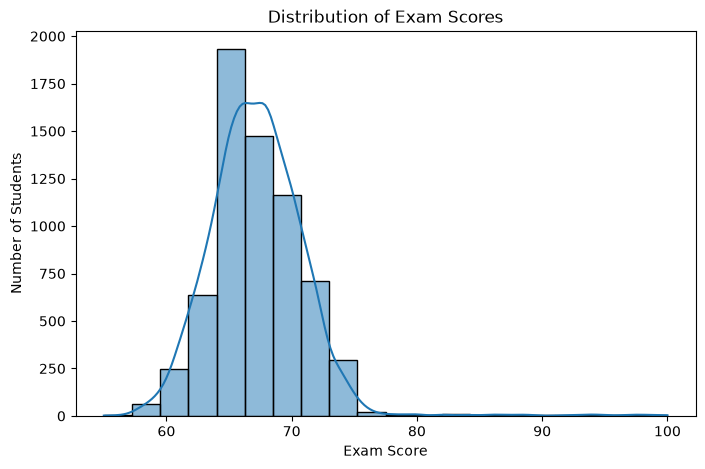

In [42]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="Exam_Score",
    bins=20,
    kde=True
)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")

plt.show()

## Exam Score Distribution

The exam scores are mainly concentrated around the mid-to-high 60s.

The distribution appears  relatively symmetric, with most observations clustered around the center.

The score of 100 appears very rarely and is located far from the main concentration of scores.


Overall, the scores show relatively limited variation for most students, although a small number of observations occur at much higher values

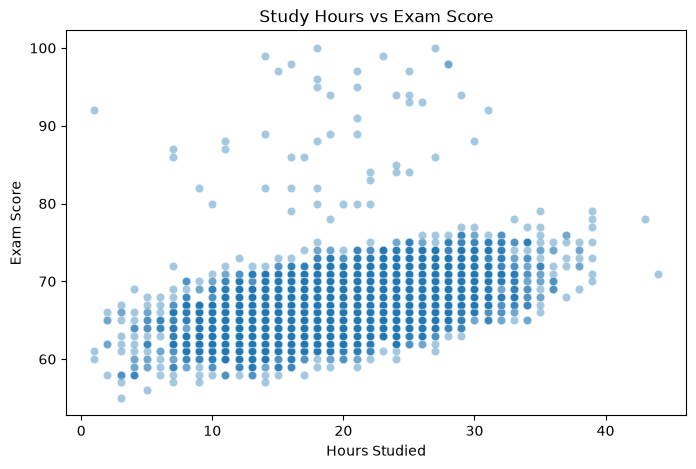

In [43]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="Hours_Studied",
    y="Exam_Score",
    alpha=0.4
)

plt.title("Study Hours vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.show()

In [44]:
df_clean["Hours_Studied"].corr(df_clean["Exam_Score"])

np.float64(0.4455575850232126)

## Study Hours and Exam Score

The correlation between `Hours_Studied` and `Exam_Score` is 0.4456.

The scatter plot shows a moderate positive relationship between study hours and exam scores.

This suggests that students who study more hours tend to have higher exam scores in this dataset. However, the relationship is not strong enough to conclude that study hours alone determine exam performance..

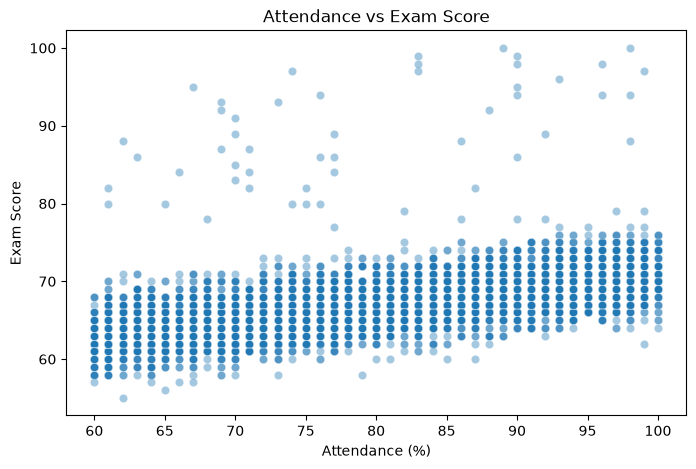

In [45]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="Attendance",
    y="Exam_Score",
    alpha=0.4
)

plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Exam Score")

plt.show()

In [46]:
df_clean["Attendance"].corr(df_clean["Exam_Score"])

np.float64(0.5812045285301283)

## Attendance and Exam Score

The correlation between `Attendance` and `Exam_Score` is 0.5812.

The scatter plot shows a positive relationship between attendance and exam scores.

Compared with `Hours_Studied` (correlation = 0.4456), attendance has a stronger positive relationship with exam performance.

This suggests that higher attendance is more strongly associated with higher exam scores than study hours in this dataset. However, this association does not prove that attendance causes higher scores.

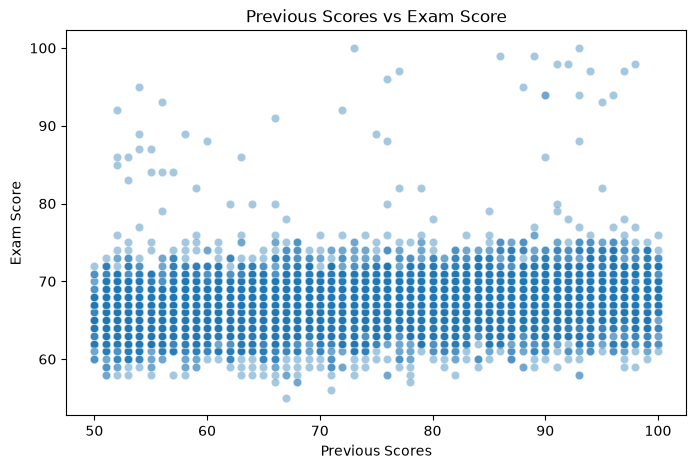

In [47]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="Previous_Scores",
    y="Exam_Score",
    alpha=0.4
)

plt.title("Previous Scores vs Exam Score")
plt.xlabel("Previous Scores")
plt.ylabel("Exam Score")

plt.show()

In [48]:
df_clean["Previous_Scores"].corr(df_clean["Exam_Score"])

np.float64(0.17508889951329237)

## Previous Scores and Exam Score

The correlation between `Previous_Scores` and `Exam_Score` is 0.175.

The scatter plot shows a weak positive relationship between previous scores and exam scores.

Compared with `Hours_Studied` (0.4456) and `Attendance` (0.5812), previous scores have a much weaker relationship with exam performance.

This suggests that previous scores have only a weak association with current exam performance in this dataset.

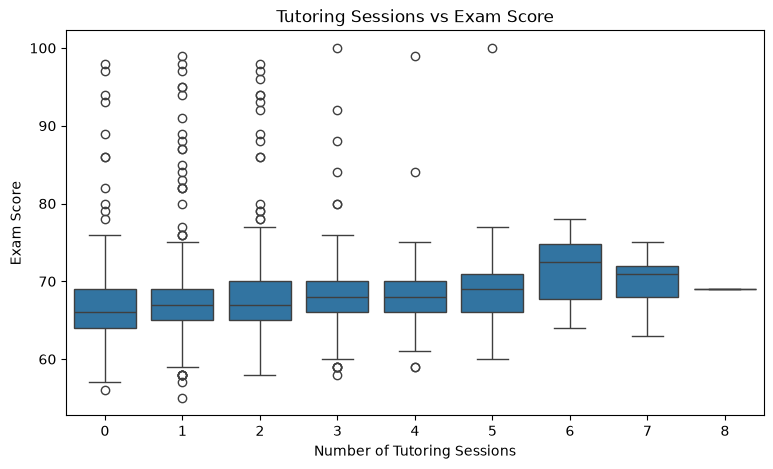

In [49]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_clean,
    x="Tutoring_Sessions",
    y="Exam_Score"
)

plt.title("Tutoring Sessions vs Exam Score")
plt.xlabel("Number of Tutoring Sessions")
plt.ylabel("Exam Score")

plt.show()

In [50]:
df_clean.groupby("Tutoring_Sessions")["Exam_Score"].agg(
    ["count", "mean", "median"]
).round(2)

,count,mean,median
Tutoring_Sessions,,,
0,1513,66.49,66.0
1,2179,66.98,67.0
2,1649,67.57,67.0
3,836,67.89,68.0
4,301,68.23,68.0
5,103,69.06,69.0
6,18,71.67,72.5
7,7,69.86,71.0
8,1,69.00,69.0


## Tutoring Sessions and Exam Score

The average and median exam scores generally increase as the number of tutoring sessions increases.

Students with 6 tutoring sessions had the highest average exam score (71.67), while students with 0 tutoring sessions had the lowest average exam score (66.49).

The box plot shows an overall upward pattern in exam scores as tutoring sessions increase, although the groups with 6 or more sessions contain very few students.

Overall, the results suggest that the number of tutoring sessions is positively associated with exam performance, although this analysis does not establish causation.

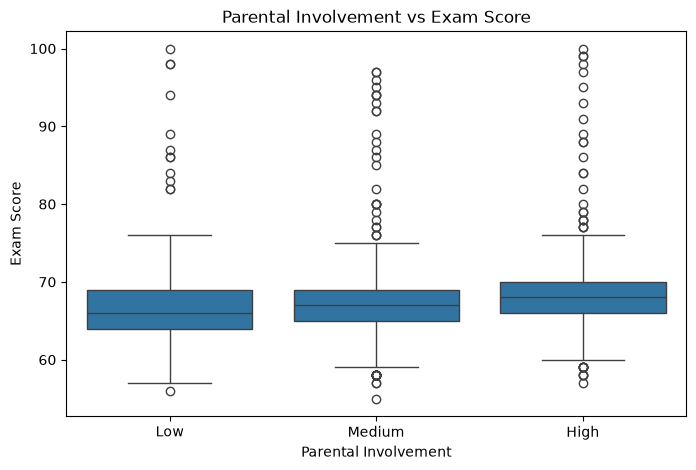

In [51]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Parental_Involvement",
    y="Exam_Score"
)

plt.title("Parental Involvement vs Exam Score")
plt.xlabel("Parental Involvement")
plt.ylabel("Exam Score")

plt.show()

In [52]:
df_clean.groupby("Parental_Involvement")["Exam_Score"].agg(
    ["count", "mean", "median"]
).round(2)


,count,mean,median
Parental_Involvement,,,
High,1908,68.09,68.0
Low,1337,66.36,66.0
Medium,3362,67.10,67.0


## Parental Involvement and Exam Score

Students with high parental involvement had the highest average exam score, while students with low parental involvement had the lowest.

The difference in average scores between the highest and lowest groups was approximately 1.73 points.

The box plot shows a gradual increase in exam scores from low to high parental involvement, although the distributions overlap considerably.

Overall, parental involvement appears to be positively associated with exam performance in this dataset.


In [53]:
correlation_matrix = df_clean.corr(numeric_only=True)

correlation_matrix

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
Hours_Studied,1.000000,-0.009908,0.010977,0.024846,-0.014282,0.004624,0.445558
Attendance,-0.009908,1.000000,-0.015918,-0.020186,0.014324,-0.022435,0.581205
Sleep_Hours,0.010977,-0.015918,1.000000,-0.021750,-0.012216,-0.000378,-0.017000
Previous_Scores,0.024846,-0.020186,-0.021750,1.000000,-0.013122,-0.011274,0.175089
Tutoring_Sessions,-0.014282,0.014324,-0.012216,-0.013122,1.000000,0.017733,0.156466
Physical_Activity,0.004624,-0.022435,-0.000378,-0.011274,0.017733,1.000000,0.027832
Exam_Score,0.445558,0.581205,-0.017000,0.175089,0.156466,0.027832,1.000000


In [54]:
exam_correlations = (
    correlation_matrix["Exam_Score"]
    .sort_values(ascending=False)
)

exam_correlations

Exam_Score           1.000000
Attendance           0.581205
Hours_Studied        0.445558
Previous_Scores      0.175089
Tutoring_Sessions    0.156466
Physical_Activity    0.027832
Sleep_Hours         -0.017000
Name: Exam_Score, dtype: float64

In [55]:
exam_correlations.drop("Exam_Score")

Attendance           0.581205
Hours_Studied        0.445558
Previous_Scores      0.175089
Tutoring_Sessions    0.156466
Physical_Activity    0.027832
Sleep_Hours         -0.017000
Name: Exam_Score, dtype: float64

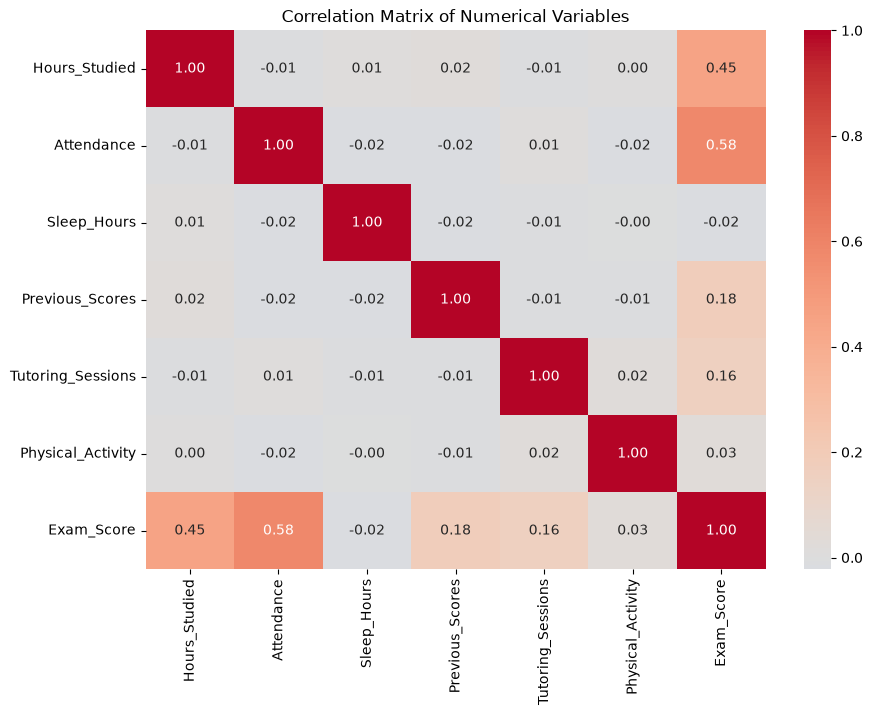

In [62]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,

    fmt=".2f",
    cmap="coolwarm",
    center=0
   
)

plt.title("Correlation Matrix of Numerical Variables")

plt.show()


## Correlation Analysis

Among the numerical variables, `c` has the strongest positive correlation with `Exam_Score`, with a correlation of `0.58`.

The next strongest relationship is `Hours_Studied`, with a correlation of `0.45`.

`Previous_Scores` has a relatively weak correlation with `Exam_Score` of 0.175.

Overall, the correlation analysis suggests that `Hours_Studied a` has the strongest observed linear association with exam performance among the numerical variables analyzed.

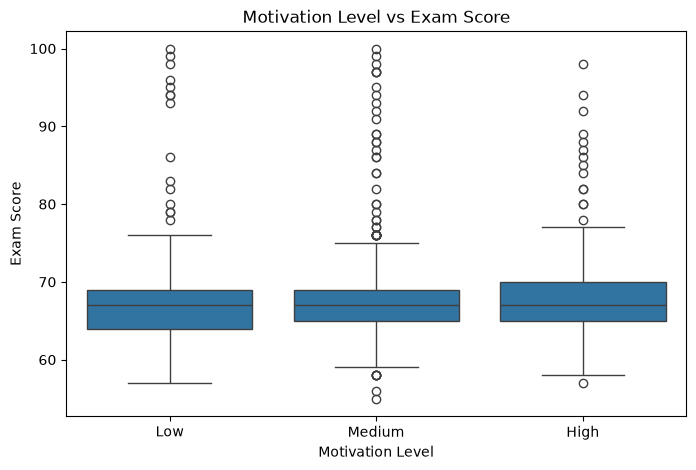

In [63]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Motivation_Level",
    y="Exam_Score"
)

plt.title("Motivation Level vs Exam Score")
plt.xlabel("Motivation Level")
plt.ylabel("Exam Score")

plt.show()


In [64]:
df_clean.groupby("Motivation_Level")["Exam_Score"].agg(
    ["count", "mean", "median"]
).round(2)




,count,mean,median
Motivation_Level,,,
High,1319,67.70,67.0
Low,1937,66.75,67.0
Medium,3351,67.33,67.0


## Motivation Level and Exam Score

Students with high motivation had the highest average exam score, while students with low motivation had the lowest.

The difference between the highest and lowest average scores was approximately 0.95 points.

The box plot shows that the distributions overlap considerably, with only a small difference in the center of the groups.

Overall, motivation level appears to have a weak positive association with exam performance in this dataset.

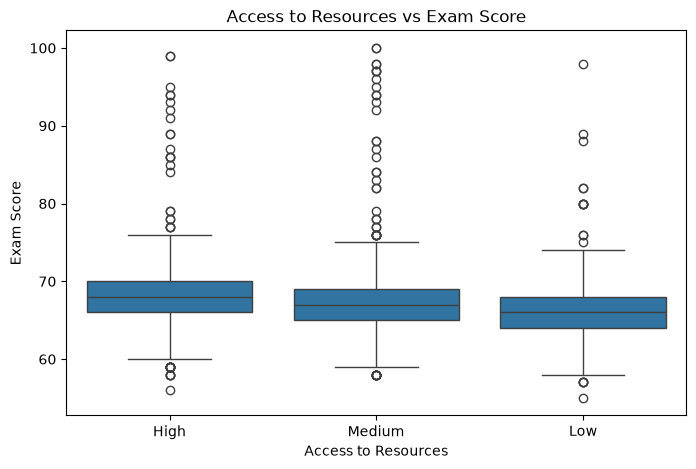

In [65]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Access_to_Resources",
    y="Exam_Score"
)

plt.title("Access to Resources vs Exam Score")
plt.xlabel("Access to Resources")
plt.ylabel("Exam Score")

plt.show()


In [66]:
df_clean.groupby("Access_to_Resources")["Exam_Score"].agg(
    ["count", "mean", "median"]
).round(2)

,count,mean,median
Access_to_Resources,,,
High,1975,68.09,68.0
Low,1313,66.20,66.0
Medium,3319,67.13,67.0


In [67]:
resource_means = df_clean.groupby(
    "Access_to_Resources"
)["Exam_Score"].mean()

resource_means.max() - resource_means.min()

np.float64(1.8888007943929637)

## Access to Resources and Exam Score

Students with high access to resources had the highest average exam score, while students with low access had the lowest.

The difference between the highest and lowest average scores was approximately 1.89 points.

The box plot shows a gradual increase in exam scores from low to high access to resources, although the distributions overlap.

Overall, access to resources appears to be positively associated with exam performance in this dataset.

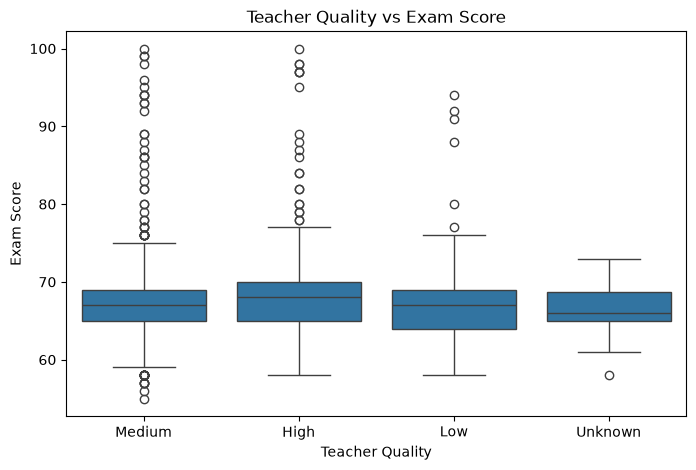

In [69]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Teacher_Quality",
    y="Exam_Score"
)

plt.title("Teacher Quality vs Exam Score")
plt.xlabel("Teacher Quality")
plt.ylabel("Exam Score")

plt.show()



In [70]:
df_clean.groupby("Teacher_Quality")["Exam_Score"].agg(
    ["count", "mean", "median"]
).round(2)

,count,mean,median
Teacher_Quality,,,
High,1947,67.68,68.0
Low,657,66.75,67.0
Medium,3925,67.11,67.0
Unknown,78,66.64,66.0


In [71]:
teacher_means = (
    df_clean[df_clean["Teacher_Quality"] != "Unknown"]
    .groupby("Teacher_Quality")["Exam_Score"]
    .mean()
)

teacher_means.max() - teacher_means.min()

np.float64(0.9230006121113519)

## Teacher Quality and Exam Score

Students reporting high teacher quality had the highest average exam score, while students reporting low teacher quality had the lowest.

The difference between the highest and lowest average scores among the known categories was approximately 0.93 points.

The box plot shows a small increase in exam scores from low to high teacher quality, although the distributions overlap considerably.

The `Unknown` category contains only 78 students, so it was not used when comparing the known teacher-quality categories.

Overall, teacher quality appears to have a weak positive association with exam performance in this dataset.

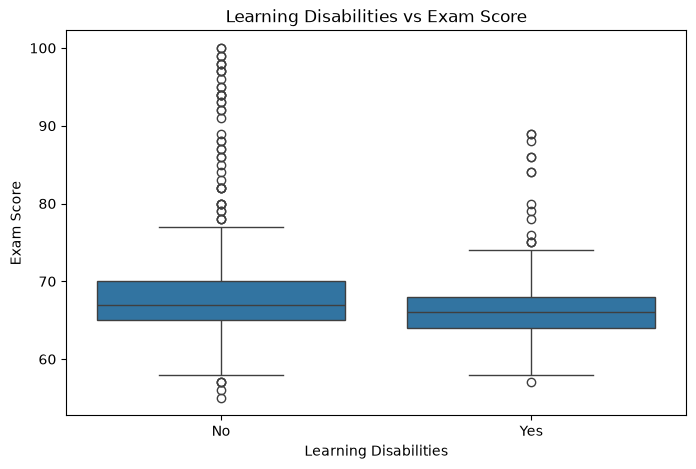

In [74]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Learning_Disabilities",
    y="Exam_Score"
)

plt.title("Learning Disabilities vs Exam Score")
plt.xlabel("Learning Disabilities")
plt.ylabel("Exam Score")

plt.show()



In [75]:
df_clean.groupby("Learning_Disabilities")["Exam_Score"].agg(
    ["count", "mean", "median"]
).round(2)

,count,mean,median
Learning_Disabilities,,,
No,5912,67.35,67.0
Yes,695,66.27,66.0


In [76]:
disability_means = df_clean.groupby(
    "Learning_Disabilities"
)["Exam_Score"].mean()

disability_means.max() - disability_means.min()


np.float64(1.0784476883986684)

## Learning Disabilities and Exam Score

Students without learning disabilities had the higher average exam score, while students with learning disabilities had the lower.

The difference between the two groups was approximately 1.08 points.

The box plot shows that the group without learning disabilities has a slightly higher center, although the two distributions overlap considerably.

Overall, learning disability status appears to have a weak association with exam performance in this dataset.

The groups are also imbalanced, with 5912 students without learning disabilities compared with 695 students with learning disabilities.

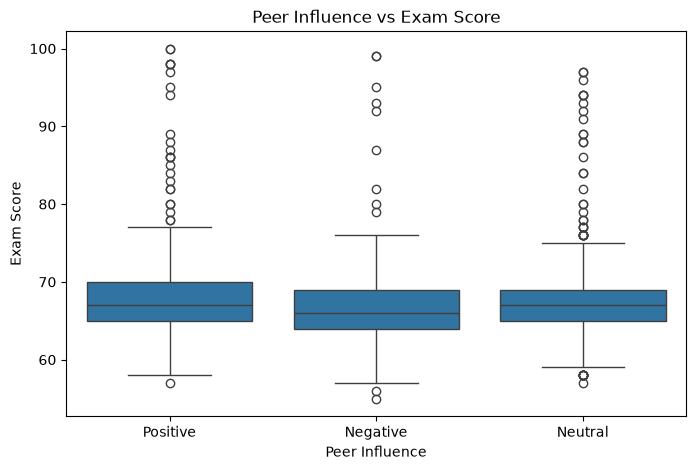

In [77]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Peer_Influence",
    y="Exam_Score"
)

plt.title("Peer Influence vs Exam Score")
plt.xlabel("Peer Influence")
plt.ylabel("Exam Score")

plt.show()

In [78]:
df_clean.groupby("Peer_Influence")["Exam_Score"].agg(
    ["count", "mean", "median"]
).round(2)

,count,mean,median
Peer_Influence,,,
Negative,1377,66.56,66.0
Neutral,2592,67.20,67.0
Positive,2638,67.62,67.0


In [79]:
peer_means = df_clean.groupby(
    "Peer_Influence"
)["Exam_Score"].mean()

peer_means.max() - peer_means.min()

np.float64(1.0585501659176089)

## Peer Influence and Exam Score

Students with positive peer influence had the highest average exam score, while students with negative peer influence had the lowest.

The difference between the highest and lowest average scores was approximately 1.06 points.

The box plot shows a gradual increase in exam scores from negative to neutral to positive peer influence, although the distributions overlap considerably.

Overall, positive peer influence appears to be weakly associated with higher exam performance in this dataset.

In [82]:
factor_summary = pd.DataFrame({
    "Factor": [
        "Attendance",
        "Hours_Studied",
        "Previous_Scores",
        "Tutoring_Sessions",
        "Access_to_Resources",
        "Parental_Involvement",
        "Motivation_Level",
        "Teacher_Quality",
        "Learning_Disabilities",
        "Peer_Influence"
    ],
    "Relationship": [
        "Moderate positive",
        "Moderate positive",
        "Weak positive",
        "Positive pattern",
        "Positive group difference",
        "Positive group difference",
        "Weak positive group difference",
        "Weak positive group difference",
        "Weak group difference",
        "Weak positive group difference"
    ]
})

factor_summary

,Factor,Relationship
0,Attendance,Moderate positive
1,Hours_Studied,Moderate positive
2,Previous_Scores,Weak positive
3,Tutoring_Sessions,Positive pattern
4,Access_to_Resources,Positive group difference
5,Parental_Involvement,Positive group difference
6,Motivation_Level,Weak positive group difference
7,Teacher_Quality,Weak positive group difference
8,Learning_Disabilities,Weak group difference
9,Peer_Influence,Weak positive group difference


## Factor comparison and key findings

In [85]:
numerical_relationships = (
    df_clean.corr(numeric_only=True)["Exam_Score"]
    .drop("Exam_Score")
    .sort_values(ascending=False)
)

numerical_relationships


Attendance           0.581205
Hours_Studied        0.445558
Previous_Scores      0.175089
Tutoring_Sessions    0.156466
Physical_Activity    0.027832
Sleep_Hours         -0.017000
Name: Exam_Score, dtype: float64

## Numerical Factors Ranking

The strongest positive linear relationship with `Exam_Score` is Attendance , with a correlation of  0.58.

The second strongest is Hours_Studied , with a correlation of 0.45.

The weakest relationship is Sleep_Hours, with a correlation of -0.02.

This ranking suggests that attendance and study time have stronger observed linear associations with exam performance than the other numerical variables. In contrast, sleep hours show almost no linear relationship with exam scores in this dataset.


In [86]:
exam_correlations = (
    df_clean.corr(numeric_only=True)["Exam_Score"]
    .drop("Exam_Score")
    .sort_values()
)

exam_correlations


Sleep_Hours         -0.017000
Physical_Activity    0.027832
Tutoring_Sessions    0.156466
Previous_Scores      0.175089
Hours_Studied        0.445558
Attendance           0.581205
Name: Exam_Score, dtype: float64

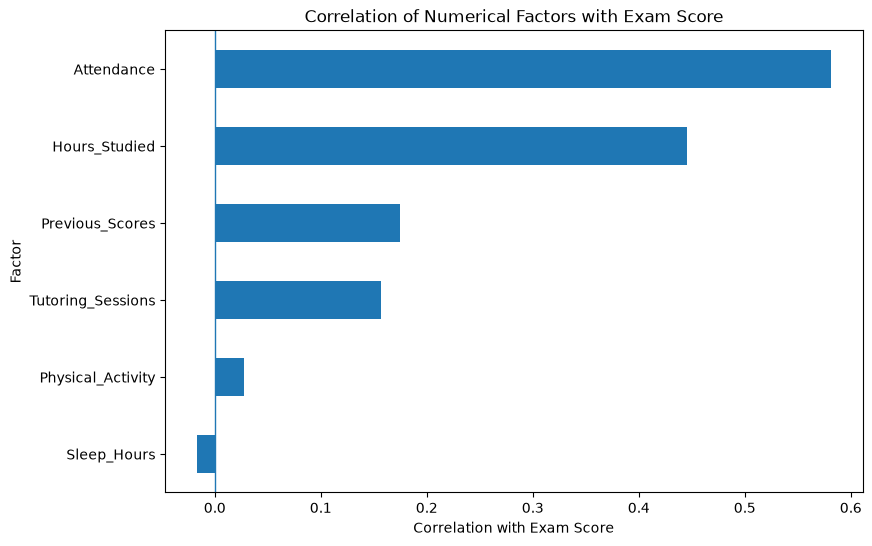

In [87]:
plt.figure(figsize=(9, 6))

exam_correlations.plot(kind="barh")

plt.title("Correlation of Numerical Factors with Exam Score")
plt.xlabel("Correlation with Exam Score")
plt.ylabel("Factor")

plt.axvline(0, linewidth=1)

plt.show()



## Correlation Ranking Visualization

The visualization shows that `Attendance` has the strongest positive linear association with `Exam_Score`, followed by `Hours_Studied`.

Most of the numerical variables have relatively weak relationships with exam performance.

`Sleep_Hours` has a correlation close to zero, indicating little linear association with `Exam_Score` in this dataset.

This visualization helps identify which numerical variables deserve further investigation.

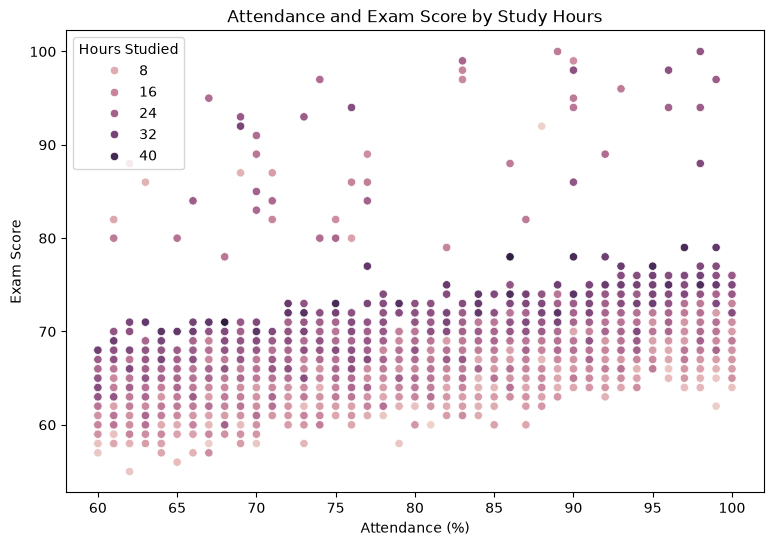

In [89]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_clean,
    x="Attendance",
    y="Exam_Score",
    hue="Hours_Studied",
    alpha=1
)

plt.title("Attendance and Exam Score by Study Hours")
plt.xlabel("Attendance (%)")
plt.ylabel("Exam Score")
plt.legend(title="Hours Studied")

plt.show()

## Attendance and Study Hours Together

The visualization shows that exam scores generally increase as attendance increases.

Students with higher study hours tend to have somewhat higher exam scores.

However, there are also students with high attendance or high study hours who do not achieve very high exam scores.

This suggests that exam performance is influenced by multiple factors rather than a single variable.


In [90]:
categorical_summary = pd.DataFrame({
    "Factor": [
        "Access_to_Resources",
        "Parental_Involvement",
        "Learning_Disabilities",
        "Peer_Influence",
        "Motivation_Level",
        "Teacher_Quality"
    ],
    "Mean_Difference": [
        1.8888,
        1.73,
        1.0784,
        1.0586,
        0.95,
        0.9230
    ]
})

categorical_summary = categorical_summary.sort_values(
    "Mean_Difference",
    ascending=False
)

categorical_summary

,Factor,Mean_Difference
0,Access_to_Resources,1.8888
1,Parental_Involvement,1.7300
2,Learning_Disabilities,1.0784
3,Peer_Influence,1.0586
4,Motivation_Level,0.9500
5,Teacher_Quality,0.9230


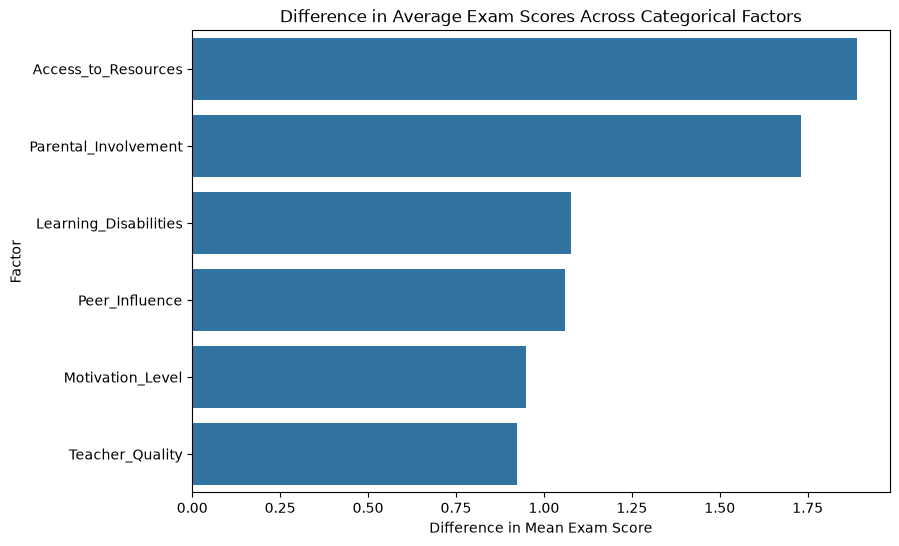

In [91]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=categorical_summary,
    x="Mean_Difference",
    y="Factor"
)

plt.title("Difference in Average Exam Scores Across Categorical Factors")
plt.xlabel("Difference in Mean Exam Score")
plt.ylabel("Factor")

plt.show()

## Categorical Factors Ranking

Among the categorical factors analyzed, `Access_to_Resources` shows the largest difference in average exam scores between its highest and lowest groups, at approximately 1.89 points.

`Parental_Involvement` shows the second-largest difference, at approximately 1.73 points.

The remaining categorical factors show differences of approximately 0.92 to 1.08 points.

Overall, access to resources and parental involvement show the largest observed group differences among the categorical variables analyzed.

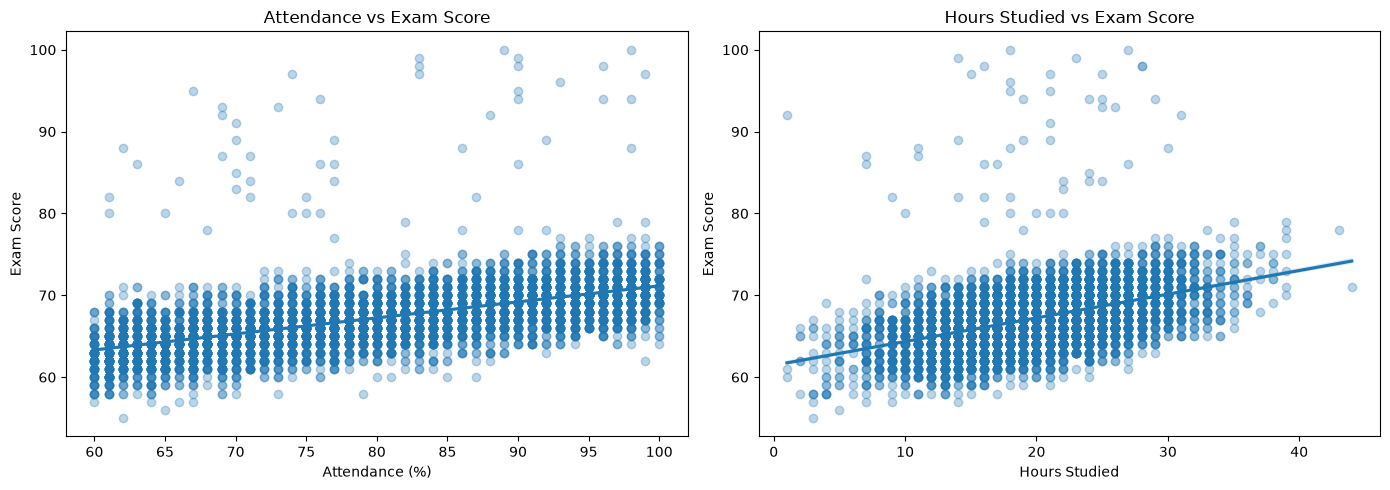

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(
    data=df_clean,
    x="Attendance",
    y="Exam_Score",
    scatter_kws={"alpha": 0.3},
    ax=axes[0]
)

axes[0].set_title("Attendance vs Exam Score")
axes[0].set_xlabel("Attendance (%)")
axes[0].set_ylabel("Exam Score")


sns.regplot(
    data=df_clean,
    x="Hours_Studied",
    y="Exam_Score",
    scatter_kws={"alpha": 0.3},
    ax=axes[1]
)

axes[1].set_title("Hours Studied vs Exam Score")
axes[1].set_xlabel("Hours Studied")
axes[1].set_ylabel("Exam Score")

plt.tight_layout()
plt.show()

## Strongest Numerical Factors

Among the numerical variables analyzed, `Attendance` and `Hours_Studied` show the strongest positive relationships with `Exam_Score`.

The relationship with attendance is stronger than the relationship with study hours, based on their correlation coefficients of 0.58 and 0.45 respectively.

However, the scatter plots also show substantial variation in exam scores at similar levels of attendance or study time.

This indicates that neither variable alone explains student exam performance.

In [93]:
df_clean["Attendance_Group"] = pd.cut(
    df_clean["Attendance"],
    bins=[59, 69, 79, 89, 100],
    labels=["60-69", "70-79", "80-89", "90-100"]
)

attendance_groups = df_clean.groupby(
    "Attendance_Group",
    observed=True
)["Exam_Score"].agg(["count", "mean", "median"]).round(2)

attendance_groups

,count,mean,median
Attendance_Group,,,
60-69,1573,64.21,64.0
70-79,1681,66.28,66.0
80-89,1607,68.04,68.0
90-100,1746,70.14,70.0


In [94]:
df_clean["Study_Hours_Group"] = pd.cut(
    df_clean["Hours_Studied"],
    bins=[0, 9, 19, 29, 39, 50],
    labels=["1-9", "10-19", "20-29", "30-39", "40-44"]
)

study_groups = df_clean.groupby(
    "Study_Hours_Group",
    observed=True
)["Exam_Score"].agg(["count", "mean", "median"]).round(2)

study_groups

,count,mean,median
Study_Hours_Group,,,
1-9,271,63.82,64.0
10-19,2808,65.99,66.0
20-29,3152,68.20,68.0
30-39,374,70.86,71.0
40-44,2,74.50,74.5


In [95]:
key_findings = pd.DataFrame({
    "Factor": [
        "Attendance",
        "Hours_Studied",
        "Access_to_Resources",
        "Parental_Involvement",
        "Previous_Scores",
        "Learning_Disabilities",
        "Peer_Influence",
        "Motivation_Level",
        "Teacher_Quality",
        "Sleep_Hours"
    ],
    "Evidence": [
        "Correlation = 0.58",
        "Correlation = 0.45",
        "Mean difference = 1.89",
        "Mean difference = 1.73",
        "Correlation = 0.175",
        "Mean difference = 1.08",
        "Mean difference = 1.06",
        "Mean difference = 0.95",
        "Mean difference = 0.92",
        "Correlation = -0.02"
    ]
})

key_findings

,Factor,Evidence
0,Attendance,Correlation = 0.58
1,Hours_Studied,Correlation = 0.45
2,Access_to_Resources,Mean difference = 1.89
3,Parental_Involvement,Mean difference = 1.73
4,Previous_Scores,Correlation = 0.175
5,Learning_Disabilities,Mean difference = 1.08
6,Peer_Influence,Mean difference = 1.06
7,Motivation_Level,Mean difference = 0.95
8,Teacher_Quality,Mean difference = 0.92
9,Sleep_Hours,Correlation = -0.02


## Key Factors Identified

Based on the exploratory analysis, `Attendance` shows the strongest observed linear association with `Exam_Score`, followed by `Hours_Studied`.

Among the categorical variables, `Access_to_Resources` and `Parental_Involvement` show the largest differences in average exam scores between groups.

Other factors, including `Previous_Scores`, `Motivation_Level`, `Teacher_Quality`, `Peer_Influence`, and `Learning_Disabilities`, show relatively weaker associations or smaller group differences.

These findings identify potential factors associated with exam performance, but they do not establish that any factor directly causes higher or lower scores.

In [97]:
attendance_groups

,count,mean,median
Attendance_Group,,,
60-69,1573,64.21,64.0
70-79,1681,66.28,66.0
80-89,1607,68.04,68.0
90-100,1746,70.14,70.0


In [98]:
study_groups


,count,mean,median
Study_Hours_Group,,,
1-9,271,63.82,64.0
10-19,2808,65.99,66.0
20-29,3152,68.20,68.0
30-39,374,70.86,71.0
40-44,2,74.50,74.5


In [99]:
key_findings = pd.DataFrame({
    "Factor": [
        "Attendance",
        "Hours_Studied",
        "Access_to_Resources",
        "Parental_Involvement",
        "Previous_Scores",
        "Learning_Disabilities",
        "Peer_Influence",
        "Motivation_Level",
        "Teacher_Quality",
        "Sleep_Hours"
    ],
    "Evidence": [
        "Correlation = 0.58",
        "Correlation = 0.45",
        "Mean difference = 1.89",
        "Mean difference = 1.73",
        "Correlation = 0.175",
        "Mean difference = 1.08",
        "Mean difference = 1.06",
        "Mean difference = 0.95",
        "Mean difference = 0.92",
        "Correlation = -0.02"
    ]
})

key_findings

,Factor,Evidence
0,Attendance,Correlation = 0.58
1,Hours_Studied,Correlation = 0.45
2,Access_to_Resources,Mean difference = 1.89
3,Parental_Involvement,Mean difference = 1.73
4,Previous_Scores,Correlation = 0.175
5,Learning_Disabilities,Mean difference = 1.08
6,Peer_Influence,Mean difference = 1.06
7,Motivation_Level,Mean difference = 0.95
8,Teacher_Quality,Mean difference = 0.92
9,Sleep_Hours,Correlation = -0.02


## Key Factors Identified

Based on the exploratory analysis, `Attendance` shows the strongest observed linear association with `Exam_Score`, followed by `Hours_Studied`.

Among the categorical variables, `Access_to_Resources` and `Parental_Involvement` show the largest differences in average exam scores between groups.

Other factors show weaker associations or smaller differences in average scores.

Overall, the analysis suggests that attendance, study time, access to resources, and parental involvement are the factors that stand out most in this dataset.

These findings describe associations observed in the data and do not establish causation.

# Advanced Visualizations

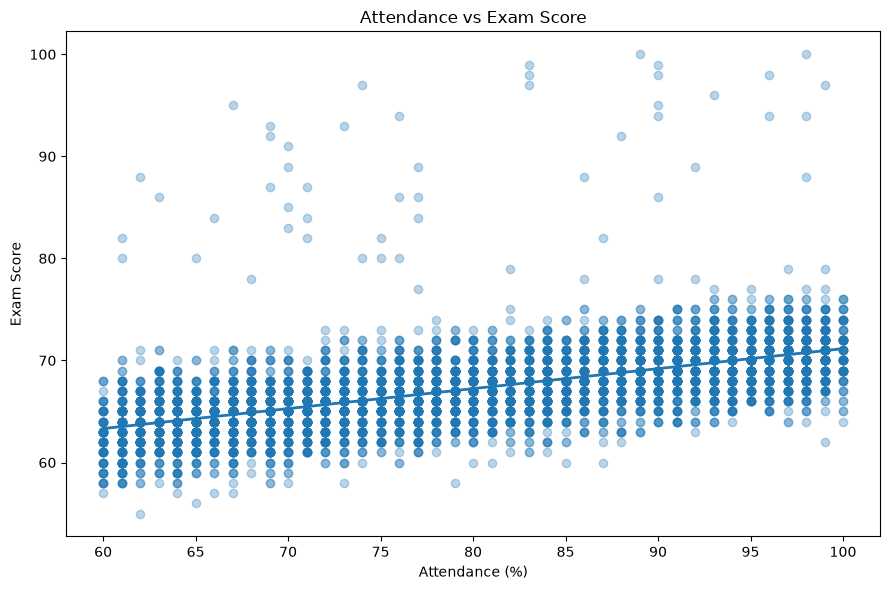

In [100]:
plt.figure(figsize=(9, 6))

sns.regplot(
    data=df_clean,
    x="Attendance",
    y="Exam_Score",
    scatter_kws={"alpha": 0.3},
    line_kws={"linewidth": 2}
)

plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Exam Score")

plt.tight_layout()
plt.show()

## Key Visualization: Attendance

Attendance shows the strongest observed linear relationship with exam performance among the numerical variables analyzed.

The upward trend indicates that students with higher attendance generally tend to have higher exam scores.

However, the points are spread around the trend line, showing that attendance alone does not explain all variation in exam performance.

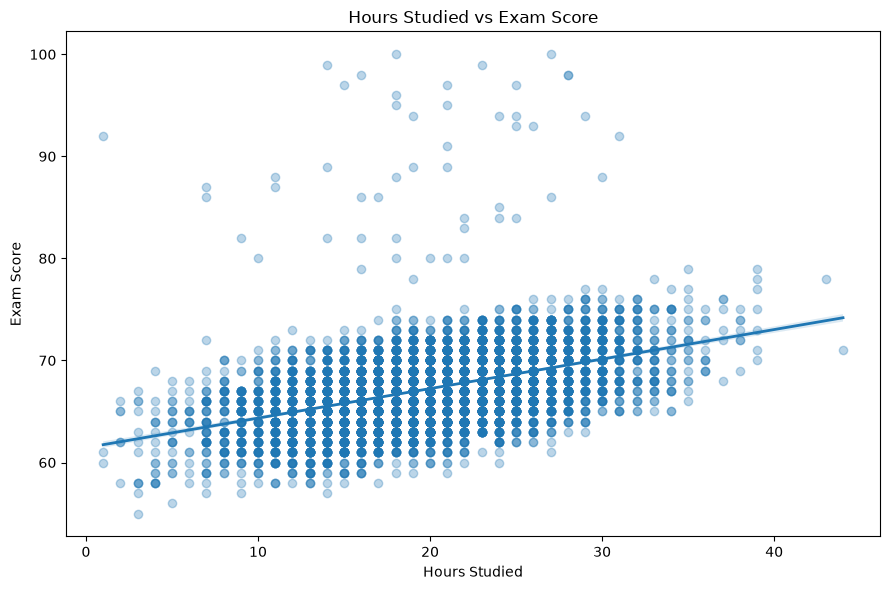

In [101]:
plt.figure(figsize=(9, 6))

sns.regplot(
    data=df_clean,
    x="Hours_Studied",
    y="Exam_Score",
    scatter_kws={"alpha": 0.3},
    line_kws={"linewidth": 2}
)

plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.tight_layout()
plt.show()


## Key Visualization: Hours Studied

Hours studied shows the second strongest observed linear relationship with exam performance among the numerical variables analyzed.

The upward trend indicates that students who study more hours generally tend to have higher exam scores.

However, there is considerable variation in scores among students with similar study hours, suggesting that study time alone does not explain exam performance.

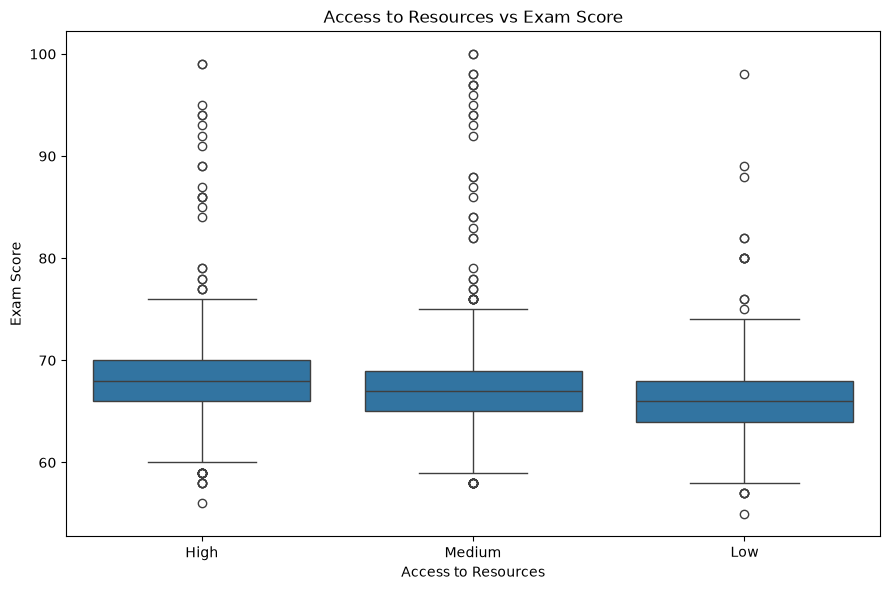

In [102]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_clean,
    x="Access_to_Resources",
    y="Exam_Score"
)

plt.title("Access to Resources vs Exam Score")
plt.xlabel("Access to Resources")
plt.ylabel("Exam Score")

plt.tight_layout()
plt.show()


## Key Visualization: Access to Resources

Students with high access to resources had the highest average exam score at 68.09, while students with low access had the lowest average at 66.20.

The difference between the highest and lowest group means was approximately 1.89 points.

The box plot shows a gradual increase in exam scores from low to high access to resources, although the distributions overlap considerably.

This suggests that access to resources is positively associated with exam performance in this dataset.

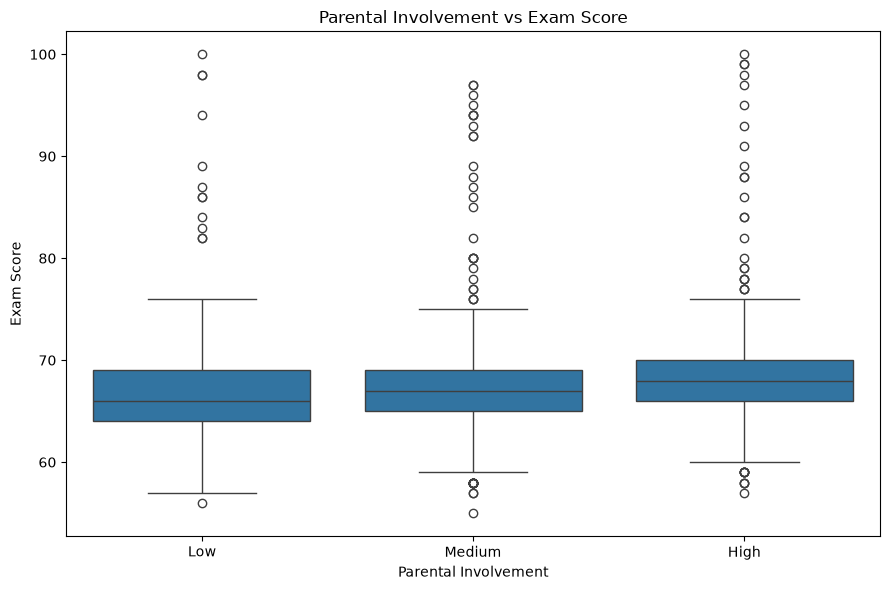

In [104]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_clean,
    x="Parental_Involvement",
    y="Exam_Score"
)

plt.title("Parental Involvement vs Exam Score")
plt.xlabel("Parental Involvement")
plt.ylabel("Exam Score")

plt.tight_layout()
plt.show()

## Key Visualization: Parental Involvement

Students with high parental involvement had the highest average exam score at 68.09, while students with low parental involvement had the lowest average at 66.36.

The difference between the highest and lowest group means was approximately 1.73 points.

The box plot shows a gradual increase in exam scores from low to high parental involvement, although the distributions overlap considerably.

This suggests that parental involvement is positively associated with exam performance in this dataset.

In [105]:
top_numerical = (
    df_clean.corr(numeric_only=True)["Exam_Score"]
    .drop("Exam_Score")
    .abs()
    .sort_values(ascending=False)
    .head(4)
)

top_numerical

Attendance           0.581205
Hours_Studied        0.445558
Previous_Scores      0.175089
Tutoring_Sessions    0.156466
Name: Exam_Score, dtype: float64

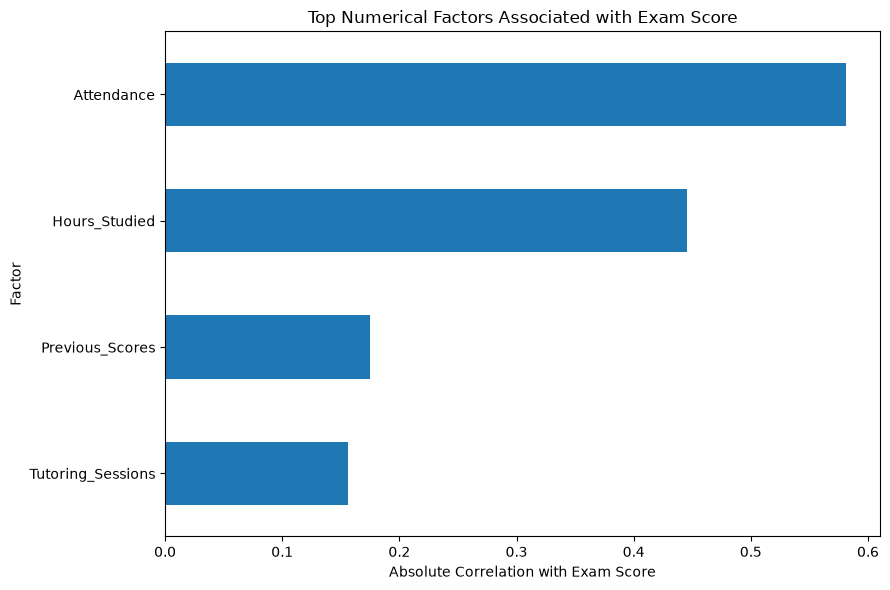

In [106]:
plt.figure(figsize=(9, 6))

top_numerical.sort_values().plot(kind="barh")

plt.title("Top Numerical Factors Associated with Exam Score")
plt.xlabel("Absolute Correlation with Exam Score")
plt.ylabel("Factor")

plt.tight_layout()
plt.show()

## Top Numerical Factors

The final comparison shows that `Attendance` has the strongest observed linear relationship with `Exam_Score`, with a correlation of 0.58, followed by `Hours_Studied` with a correlation of 0.45.

`Previous_Scores` and `Tutoring_Sessions` show considerably weaker positive relationships, with correlations of 0.18 and 0.16 respectively.

Overall, attendance and study time stand out as the two numerical factors most strongly associated with exam performance in this dataset. However, neither factor alone explains all of the variation in exam scores.


In [ ]:
top_numerical